In [1]:
from typing import List, TypedDict, Literal
import time
import re
from pydantic import BaseModel

import os
import pathlib

from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
NOTEBOOK_DIR = pathlib.Path().resolve()

CHROMA_PATH = NOTEBOOK_DIR / "chroma_db"

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-miniLM-L6-v2")

if (CHROMA_PATH / "chroma.sqlite3").exists():
    print("Loading existing vector store from disk...")
    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
else:
    print("Loading PDFs, chunking, and creating vector store...")
    docs = (
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book1.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book2.pdf").load() +
        PyPDFLoader(NOTEBOOK_DIR / "documents" / "book3.pdf").load()
    )
    chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
    for d in chunks:
        d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

    vector_store = Chroma(
        collection_name="rag_collection",
        embedding_function=embeddings,
        persist_directory=str(CHROMA_PATH),
    )
    for i in range(0, len(chunks), 1000):
        vector_store.add_documents(chunks[i:i+1000])
        print(f"Indexed Batch {i}")
    print(f"Indexed {len(chunks)} chunks.")

Loading existing vector store from disk...


In [3]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [4]:
# 4) LLM + prompt
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

In [6]:
def retrieve_node(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [7]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
UPPER_TH = 0.7
LOWER_TH = 0.3

class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)
        if out.score > LOWER_TH:
            good.append(d)

    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }

def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> Literal["refine", "fail", "ambiguous"]:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "fail"
    else:
        return "ambiguous"


# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: str

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINE (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]
    context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep.lower() == "true":
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


# -----------------------------
# GENERATE (using refined context)
# -----------------------------
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state["refined_context"]})
    return {"answer": out.content}


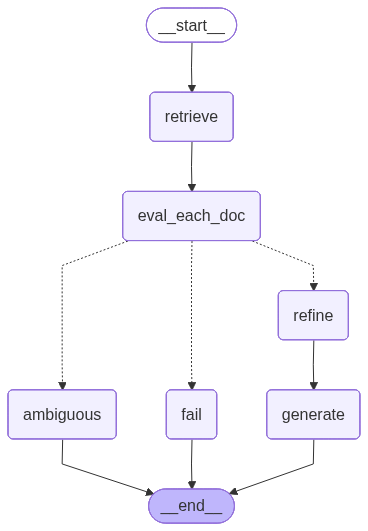

In [8]:
g = StateGraph(State)
g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {"refine": "refine", "fail": "fail", "ambiguous": "ambiguous"}
)
g.add_edge("refine", "generate")
g.add_edge("generate", END)
g.add_edge("fail", END)
app = g.compile()

app

In [9]:
# 5) Run
res = app.invoke({"question": "Explain the bias–variance tradeoff", "docs": [], "good_docs": [], "verdict": "", "reason": "", "strips": [], "kept_strips": [], "refined_context": "", "answer": ""})
print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nANSWER:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

ANSWER:
 * The bias-variance tradeoff refers to the balance between the bias and variance of a model, where very flexible models have low bias and high variance, and relatively rigid models have high bias and low variance.
* The goal is to minimize the expected loss, which is decomposed into the sum of a (squared) bias, a variance, and a constant noise term.
* The minimum value of (bias)² + variance occurs when the model is optimally balanced between bias and variance.
* Small values of λ (regularization coefficient) allow the model to become finely tuned to the noise on each individual, resulting in low bias and high variance.
* Large values of λ result in high bias and low variance.
* The optimal model is the one that leads to the best balance between bias and variance, resulting in the minimum expected loss.


In [10]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 151
Figure 3.6 Plot of squared bias and variance,
together with their sum, correspond-
ing to the results shown in Fig-
ure 3.5. Also shown is the average
test set error for a test data set size
of 1000 points. The minimum value
of (bias)2 + variance occurs around
ln λ = −0.31, which is close to the
value that gives the minimum error
on the test data.
lnλ
−3 −2 −1 0 1 2
0
0.03
0.06
0.09
0.12
0.15
(bias)2
variance
(bias)2 + variance
test error
ﬁt a model with 24 Gaussian basis functions by minimizing the regularized error
function (3.27) to give a prediction function y(l)(x) as shown in Figure 3.5. The
top row corresponds to a large value of the regularization coefﬁcient λ that gives low
variance (because the red curves in the left plot look similar) but high bias (because
****************************************************************************************************
with respect to multiple data sets.
We can also examine the bias-variance trade

In [11]:
print(res['refined_context'])

The Bias-Variance Decomposition 151 Figure 3.6 Plot of squared bias and variance, together with their sum, correspond- ing to the results shown in Fig- ure 3.5.
The minimum value of (bias)2 + variance occurs around ln λ = −0.31, which is close to the value that gives the minimum error on the test data.
The top row corresponds to a large value of the regularization coefﬁcient λ that gives low variance (because the red curves in the left plot look similar) but high bias (because with respect to multiple data sets.
We can also examine the bias-variance trade-off quantitatively for this example.
The average prediction is estimated from y(x)= 1 L L∑ l=1 y(l)(x) (3.45) and the integrated squared bias and integrated variance are then given by (bias)2 = 1 N N∑ n=1 {y(xn) − h(xn)}2 (3.46) variance = 1 N N∑ n=1 1 L L∑ l=1 { y(l)(xn) − y(xn) }2 (3.47) where the integral over x weighted by the distribution p(x) is approximated by a ﬁnite sum over data points drawn from that distribution.
We see th